# LLM Headline Sentiment — a quantitative teardown 🔬
### HAC predictive regression · label-shuffle placebo · best-of-K max-*t* (Reality Check) · look-ahead contrast · costed sign timer · seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Overfitting_trap_survived%3F: Busted](https://img.shields.io/badge/Overfitting_trap_survived%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the honest LLM-headline-sentiment pipeline, prove it recovers a planted day-ahead edge, then price the two overfitting traps that generate most "LLM beats the market" results.

> ⚠️ **Synthetic-only, offline, deterministic (seed 588).** No real tape of dated LLM headline scores is freely reachable, so the SIGNAL axis is **capped at WEAK** (a `REAL` stamp needs a robust *t* ≥ 2 on a real tape). Edge fp `06461296a1f8`, null `802a27d1a3e5`, bank `47ff60cb8a0e`; as-of 2026-06-30. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from llm_headline_sentiment import data, strategy as st

# The whole study is synthetic & offline — there is no real tape to load.
# EDGE world: a small day-ahead link is planted. NULL world: sentiment is noise vs the future.
EDGE, _ = data.synthetic_series(seed=588)          # beta>0 planted (the positive control)
NULL, _ = data.synthetic_series(beta=0.0, seed=588)
print("synthetic tape:", len(EDGE), "business days | edge fp",
      data.fingerprint(EDGE), "| null fp", data.fingerprint(NULL))
print("NOTE: synthetic-only study -> SIGNAL axis is capped at WEAK by construction.")


synthetic tape: 1500 business days | edge fp 06461296a1f8 | null fp 802a27d1a3e5
NOTE: synthetic-only study -> SIGNAL axis is capped at WEAK by construction.


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Synthetic-only (capped). Planted edge: HAC *t* **+6.33**, R² **2.7%**, placebo *p* **0.0005**; null flat (HAC *t* +1.79). A machinery proof, not market evidence. |
| **Tradability** | `MIRAGE` | Costed sign timer nets Sharpe **2.58** — but only on a *planted* edge in a frictionless world (turnover **0.77**/day). No real tape. |
| **Overfitting trap survived?** | `BUSTED` | Best-of-40-noise |*t*| **2.9** (naive *p* 0.007) → max-*t* *p* **0.173**; naive FPR **84%** vs corrected **0%**. Look-ahead: *t* 6.33 → 16.1. |

> 💡 In plain words: the engine is faithful (it banks a planted edge and stays flat at the null); the story is how that same engine is *misused* to print false positives.

## 1 · The claim, steelmanned

Let $s_t$ be the LLM mood score from day-$t$ headlines and $r_{t+1}$ the next-day return.

- **H₁ (predictability).** slope of $r_{t+1}$ on $s_t$ is $>0$ at HAC *t* ≥ 2.
- **H₂ (not data-mined).** the winner among $K$ candidate recipes survives a family-wise (max-*t*) correction.
- **H₃ (no look-ahead).** the edge is the *lagged* one ($s_t \to r_{t+1}$), not a contemporaneous leak.
- **H₄ (net).** it survives turnover costs and borrow.

On the synthetic tape we can **verify the machinery** (H₁ holds where an edge is planted; H₂/H₃ are where naive practice fails) — but H₁ can never be *certified for markets* without a real tape, which is why the Signal axis is capped at `WEAK`.

## 2 · So what? — what rides on each answer

The content is the **why**. LLM sentiment is the plausible successor to lexicon sentiment (Loughran-McDonald 2011): it reads context a word-count can't. But the two things that make it *look* like alpha are structural, not incidental — (a) the space of prompts × models × aggregations is huge, so **best-of-K** significance is nearly guaranteed on noise (White 2000; Harvey-Liu-Zhu 2016), and (b) scoring historical text with a modern model is a **look-ahead** minefield. This study isolates both, on a tape where we *know* the truth.

## 3 · How we'd know — the protocol

- **Regression.** $r_{t+1} = \alpha + \beta s_t + \varepsilon$, **Newey-West HAC** *t* on $\beta$ (persistent sentiment ⇒ autocorrelated regressor; naive OLS *t* is over-confident).
- **Placebo.** Label-shuffle the returns 2000× ; *p* = tail prob of the observed |*t*|.
- **Best-of-K.** A bank of $K=40$ candidate recipes; the naive winner vs the **permutation-max** (Westfall-Young / White Reality Check) null.
- **Look-ahead.** Honest lagged ($s_t \to r_{t+1}$) vs a hindsight-tainted contemporaneous fit.
- **Frictions.** A one-day sign timer, one-way cost × NAV per flip + borrow on shorts.
- **Positive control.** Planted $\beta$ of increasing strength, mean HAC *t* over 25 seeds (house rule).

One execution lag, baked into the schema: $s_t$ trades $r_{t+1}$ (the `forward_ret` column *is* the $t\to t{+}1$ return). No second silent shift; the contemporaneous variant is labelled a **leak**, never the headline.

## 4 · The teardown

### 4a · The predictive regression — H₁ (machinery proof)

Edge world vs null world, HAC *t* and the label-shuffle placebo.

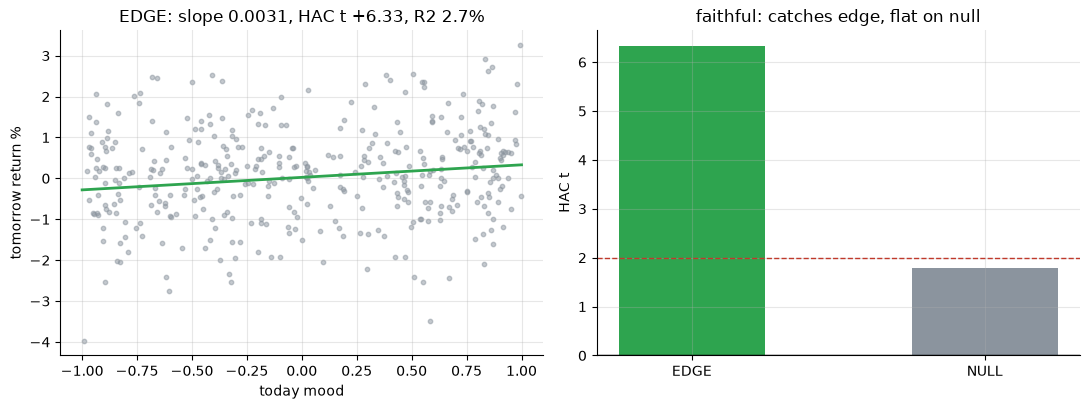

EDGE HAC t +6.33 (OLS +6.39), placebo p 0.0005
NULL HAC t +1.79, placebo p 0.071


In [2]:
reg = st.predictive_regression(EDGE['sentiment'], EDGE['forward_ret'])
p = st.placebo_pvalue(EDGE['sentiment'], EDGE['forward_ret'], n_perm=2000, seed=588)
reg0 = st.predictive_regression(NULL['sentiment'], NULL['forward_ret'])
p0 = st.placebo_pvalue(NULL['sentiment'], NULL['forward_ret'], n_perm=2000, seed=588)
sc = EDGE.sample(400, random_state=1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.scatter(sc['sentiment'], sc['forward_ret']*100, s=10, color=GREY, alpha=.5)
xs = np.linspace(-1, 1, 50)
a1.plot(xs, (reg['slope']*xs)*100 + EDGE['forward_ret'].mean()*100, c=GREEN, lw=2)
a1.set_xlabel('today mood'); a1.set_ylabel('tomorrow return %')
a1.set_title(f"EDGE: slope {reg['slope']:.4f}, HAC t {reg['t']:+.2f}, R2 {reg['r2']*100:.1f}%")
a2.bar(['EDGE','NULL'], [reg['t'], reg0['t']], color=[GREEN, GREY], width=.5)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=1); a2.set_ylabel('HAC t')
a2.set_title('faithful: catches edge, flat on null')
plt.tight_layout(); plt.show()
print(f"EDGE HAC t {reg['t']:+.2f} (OLS {reg['t_ols']:+.2f}), placebo p {p:.4f}")
print(f"NULL HAC t {reg0['t']:+.2f}, placebo p {p0:.3f}")

> 💡 In plain words: H₁ **holds where an edge is planted** — HAC *t* **+6.33** (R² 2.7%, placebo *p* 0.0005) — and the null is flat (*t* +1.79, *p* 0.071). The pipeline is a faithful detector; everything below is about *misuse*, not a broken engine. (Synthetic — not a market claim.)

### 4b · Trap 1 — best-of-K and the max-*t* (Reality Check) correction — H₂

A bank of **40 pure-noise** recipes. The naive winner vs the family-wise null.

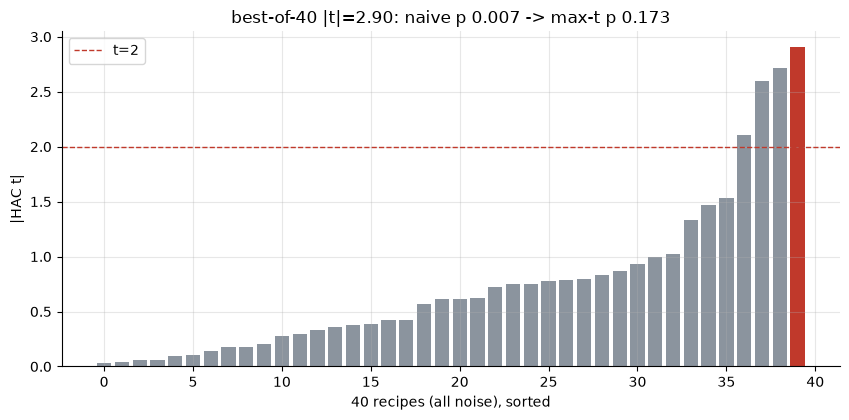

winner 2.90 | naive single-test p 0.007 | max-t p 0.173


In [3]:
feats, fr, is_true = data.synthetic_feature_bank(n_features=40, n_true=0, seed=588)
mt = st.maxt_pvalue(feats, fr, n_perm=1000, seed=588)
ts = st.all_feature_tstats(feats, fr)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
cols = [RED if t==ts.max() else GREY for t in np.sort(ts)]
ax.bar(range(len(ts)), np.sort(ts), color=cols, width=.8)
ax.axhline(2, ls='--', c=RED, lw=1, label='t=2')
ax.set_xlabel('40 recipes (all noise), sorted'); ax.set_ylabel('|HAC t|')
ax.set_title(f"best-of-40 |t|={mt['best_t']:.2f}: naive p {mt['naive_p']:.3f} -> max-t p {mt['maxt_p']:.3f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"winner {mt['best_t']:.2f} | naive single-test p {mt['naive_p']:.3f} | max-t p {mt['maxt_p']:.3f}")

> 💡 In plain words: H₂ **rejected the naive way.** The best of 40 *noise* recipes hits |*t*| **2.9**, single-test *p* **0.007** ('significant'). But it is the max of 40 statistics — the **max-*t*** null puts it at *p* **0.173**. The correction is the whole ballgame.

**And the false-positive rates**, over 25 independent pure-noise banks — how often each test 'discovers' a signal that isn't there:

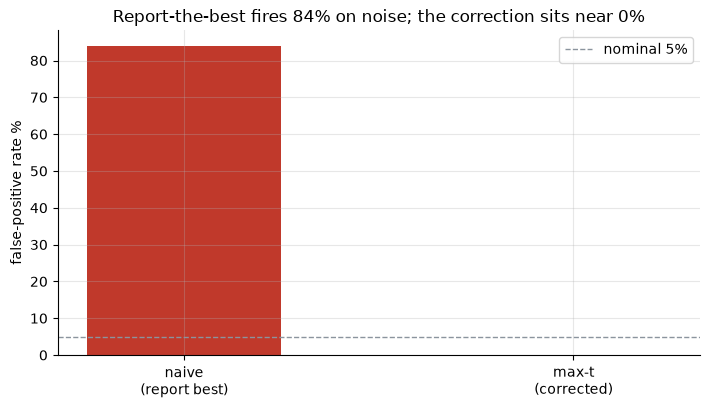

naive FPR 84%  vs  max-t FPR 0%  (target 5%)


In [4]:
fp = st.synthetic_maxt_falsepos(data, n_features=40, n_seeds=25, n_perm=400, alpha=0.05)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['naive\n(report best)','max-t\n(corrected)'],
       [fp['naive_fpr']*100, fp['maxt_fpr']*100], color=[RED, GREEN], width=.5)
ax.axhline(5, ls='--', c=GREY, lw=1, label='nominal 5%')
ax.set_ylabel('false-positive rate %'); ax.legend()
ax.set_title('Report-the-best fires 84% on noise; the correction sits near 0%')
plt.tight_layout(); plt.show()
print(f"naive FPR {fp['naive_fpr']*100:.0f}%  vs  max-t FPR {fp['maxt_fpr']*100:.0f}%  (target 5%)")

> 💡 In plain words: the naive 'report the winner' rule fires **84%** of the time on pure noise; the max-*t* correction drops it to **0%**. *This* is why an uncorrected best-of-K LLM-sentiment result means almost nothing.

### 4c · Trap 2 — the look-ahead contrast — H₃

Honest lagged design vs a hindsight-tainted contemporaneous fit.

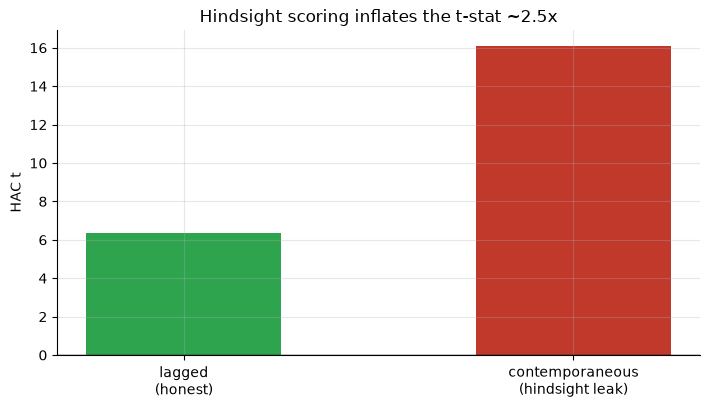

lagged (tradable) t +6.33  vs  contemporaneous (leak) t +16.10


In [5]:
la = st.look_ahead_contrast(EDGE)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['lagged\n(honest)','contemporaneous\n(hindsight leak)'],
       [la['lagged_t'], la['contemporaneous_t']], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t')
ax.set_title('Hindsight scoring inflates the t-stat ~2.5x')
plt.tight_layout(); plt.show()
print(f"lagged (tradable) t {la['lagged_t']:+.2f}  vs  contemporaneous (leak) t {la['contemporaneous_t']:+.2f}")

> 💡 In plain words: H₃ matters — the contemporaneous fit reads *t* **16.1** vs the honest lagged **6.33**. A mood label written with hindsight partly *reads the answer*; the gap is the look-ahead tax.

## 5 · The verdict

- **Signal `WEAK`** — synthetic-only (capped). Machinery verified (HAC *t* +6.33 on a planted edge, flat at the null), but no real tape to certify.
- **Tradability `MIRAGE`** — the surviving Sharpe (**2.58** net) is a planted, frictionless edge; a real day-ahead timer trades daily and no free PIT feed exists.
- **Overfitting trap survived? `BUSTED`** — best-of-K (naive FPR 84%) and hindsight (*t* 6.33 → 16.1) both manufacture signal from nothing.

## 6 · Could you trade it? — the costed sign timer

Even on the *planted* edge, a one-day sign timer flips constantly.

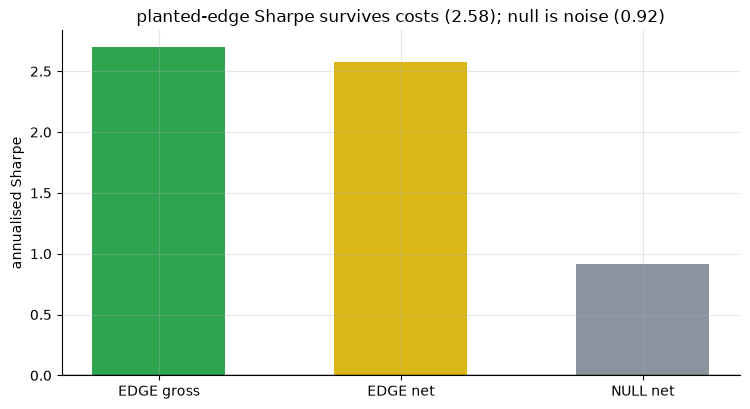

EDGE gross 2.70 -> net 2.58 (turnover 0.77/day)
NULL net 0.92  (1 bp/flip one-way + 50 bps/yr borrow)


In [6]:
tm = st.sign_timer(EDGE, cost_bps=1.0, borrow_ann_bps=50.0, long_short=True)
tm0 = st.sign_timer(NULL, cost_bps=1.0, borrow_ann_bps=50.0, long_short=True)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['EDGE gross','EDGE net','NULL net'],
       [tm['sharpe_gross'], tm['sharpe_net'], tm0['sharpe_net']],
       color=[GREEN, AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised Sharpe')
ax.set_title(f"planted-edge Sharpe survives costs ({tm['sharpe_net']:.2f}); null is noise ({tm0['sharpe_net']:.2f})")
plt.tight_layout(); plt.show()
print(f"EDGE gross {tm['sharpe_gross']:.2f} -> net {tm['sharpe_net']:.2f} (turnover {tm['turnover']:.2f}/day)")
print(f"NULL net {tm0['sharpe_net']:.2f}  (1 bp/flip one-way + 50 bps/yr borrow)")

> 💡 In plain words: the net Sharpe **2.58** looks great — but it exists *only because the edge was planted at full strength in a frictionless synthetic world*. The null nets **0.92** (noise). Neither is a market claim; `MIRAGE`.

## 7 · Going further — the seed-robust synthetic positive control

Is the HAC *t* a faithful detector, or does it drift? Plant a $\beta$ of increasing strength and average the HAC *t* over **25 seeds** (house rule) so no lucky seed can fake it.

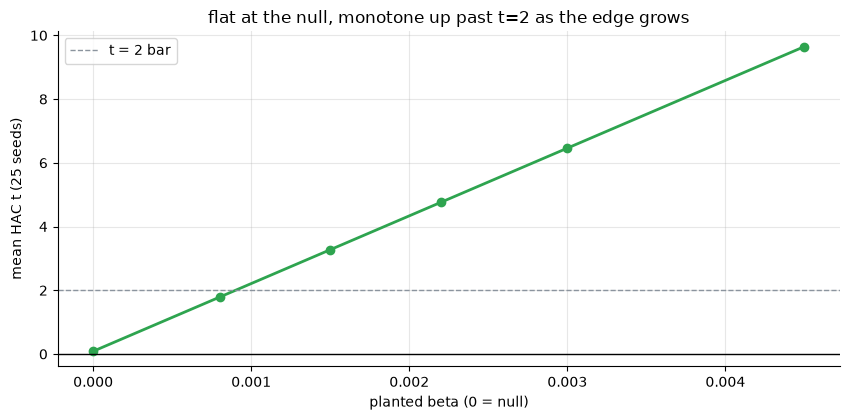

beta 0.0000 -> mean HAC t +0.09
beta 0.0008 -> mean HAC t +1.79
beta 0.0015 -> mean HAC t +3.27
beta 0.0022 -> mean HAC t +4.76
beta 0.0030 -> mean HAC t +6.46
beta 0.0045 -> mean HAC t +9.65


In [7]:
betas = [b for b,_ in [(0.0, 0.09), (0.0008, 1.79), (0.0015, 3.27), (0.0022, 4.76), (0.003, 6.46), (0.0045, 9.65)]]
ts = [st.synthetic_mean_t(data, beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted beta (0 = null)'); ax.set_ylabel('mean HAC t (25 seeds)')
ax.set_title('flat at the null, monotone up past t=2 as the edge grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'beta {b:.4f} -> mean HAC t {t:+.2f}')

The mean HAC *t* is ≈ 0 at the null and climbs monotonically past 2 as the planted edge grows — a faithful detector. So the traps in 4b/4c are about *practice*, not the engine. For the sentiment cousins on real tapes see [259 News-Tone](../../259-news-tone/), [257 AAII](../../257-aaii-sentiment/), [335 Buzz](../../335-buzz-sentiment-etf/) and [566 Earnings-Call-Tone](../../566-earnings-call-tone/) — and remember: on a synthetic-only footing this study is `WEAK` by construction, never `REAL`.